In [2]:
import zipfile

# Extract TB dataset
with zipfile.ZipFile("tb_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("tb_data")

# Extract Pneumonia dataset
with zipfile.ZipFile("pneumonia_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("pneumonia_data")

In [3]:
import os

base_path = "combined_dataset"
folders = ["train", "valid", "test"]
classes = ["Normal", "Pneumonia", "Tuberculosis"]

for folder in folders:
    for cls in classes:
        os.makedirs(os.path.join(base_path, folder, cls), exist_ok=True)

print("Combined folder structure created successfully!")

Combined folder structure created successfully!


In [4]:
import shutil

# Copy Pneumonia dataset
for split in ["train", "valid", "test"]:
    
    # NORMAL
    src_normal = f"pneumonia_data/{split}/NORMAL"
    dst_normal = f"combined_dataset/{split}/Normal"
    
    if os.path.exists(src_normal):
        for file in os.listdir(src_normal):
            shutil.copy(os.path.join(src_normal, file), dst_normal)
    
    # PNEUMONIA
    src_pneu = f"pneumonia_data/{split}/PNEUMONIA"
    dst_pneu = f"combined_dataset/{split}/Pneumonia"
    
    if os.path.exists(src_pneu):
        for file in os.listdir(src_pneu):
            shutil.copy(os.path.join(src_pneu, file), dst_pneu)

print("Pneumonia dataset copied successfully!")

Pneumonia dataset copied successfully!


In [5]:
# Copy TB dataset
for split in ["train", "valid", "test"]:
    
    # Normal (TB dataset)
    src_normal = f"tb_data/{split}/Normal"
    dst_normal = f"combined_dataset/{split}/Normal"
    
    if os.path.exists(src_normal):
        for file in os.listdir(src_normal):
            shutil.copy(os.path.join(src_normal, file), dst_normal)
    
    # Tuberculosis
    src_tb = f"tb_data/{split}/Tuberculosis"
    dst_tb = f"combined_dataset/{split}/Tuberculosis"
    
    if os.path.exists(src_tb):
        for file in os.listdir(src_tb):
            shutil.copy(os.path.join(src_tb, file), dst_tb)

print("TB dataset copied successfully!")

TB dataset copied successfully!


In [6]:
for split in ["train", "valid", "test"]:
    print(f"\n{split.upper()} SET")
    for cls in ["Normal", "Pneumonia", "Tuberculosis"]:
        path = f"combined_dataset/{split}/{cls}"
        print(cls, ":", len(os.listdir(path)))


TRAIN SET
Normal : 1491
Pneumonia : 2973
Tuberculosis : 1458

VALID SET
Normal : 805
Pneumonia : 861
Tuberculosis : 139

TEST SET
Normal : 241
Pneumonia : 411
Tuberculosis : 69


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "combined_dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_test_datagen.flow_from_directory(
    "combined_dataset/valid",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = val_test_datagen.flow_from_directory(
    "combined_dataset/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 5922 images belonging to 3 classes.
Found 1805 images belonging to 3 classes.
Found 721 images belonging to 3 classes.


In [8]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = train_generator.classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: 1.323943661971831, 1: 0.6639757820383451, 2: 1.353909465020576}


In [9]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load pretrained ResNet50
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 29s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [1]:
import os
import shutil

all_tb_images = []

for split in ["train", "valid", "test"]:
    path = f"tb_data/{split}/Tuberculosis"
    if os.path.exists(path):
        for img in os.listdir(path):
            all_tb_images.append(os.path.join(path, img))

print("Total TB Images:", len(all_tb_images))

Total TB Images: 1666


In [2]:
from sklearn.model_selection import train_test_split

tb_train, tb_temp = train_test_split(all_tb_images, test_size=0.30, random_state=42)
tb_valid, tb_test = train_test_split(tb_temp, test_size=0.50, random_state=42)

print("Train:", len(tb_train))
print("Valid:", len(tb_valid))
print("Test:", len(tb_test))

Train: 1166
Valid: 250
Test: 250


In [4]:
import shutil

for split in ["train", "valid", "test"]:
    tb_path = f"combined_dataset/{split}/Tuberculosis"
    shutil.rmtree(tb_path)
    os.makedirs(tb_path)

In [5]:
def copy_images(image_list, destination):
    for img_path in image_list:
        shutil.copy(img_path, destination)

copy_images(tb_train, "combined_dataset/train/Tuberculosis")
copy_images(tb_valid, "combined_dataset/valid/Tuberculosis")
copy_images(tb_test, "combined_dataset/test/Tuberculosis")

print("TB dataset rebalanced successfully!")

TB dataset rebalanced successfully!


In [6]:
for split in ["train", "valid", "test"]:
    print(f"\n{split.upper()} SET")
    for cls in ["Normal", "Pneumonia", "Tuberculosis"]:
        path = f"combined_dataset/{split}/{cls}"
        print(cls, ":", len(os.listdir(path)))


TRAIN SET
Normal : 1491
Pneumonia : 2973
Tuberculosis : 1166

VALID SET
Normal : 805
Pneumonia : 861
Tuberculosis : 250

TEST SET
Normal : 241
Pneumonia : 411
Tuberculosis : 250


In [7]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    "combined_dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_test_datagen.flow_from_directory(
    "combined_dataset/valid",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = val_test_datagen.flow_from_directory(
    "combined_dataset/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 5630 images belonging to 3 classes.
Found 1916 images belonging to 3 classes.
Found 902 images belonging to 3 classes.


In [8]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: 1.2586630896490052, 1: 0.6312366857270995, 2: 1.6094911377930246}


In [10]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load base model
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all layers first
for layer in base_model.layers:
    layer.trainable = False

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weights
)

C:\Users\User\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.5600 - loss: 1.0914 - val_accuracy: 0.7041 - val_loss: 0.6288
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - accuracy: 0.7533 - loss: 0.6127 - val_accuracy: 0.8027 - val_loss: 0.4440
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.8030 - loss: 0.4674 - val_accuracy: 0.8507 - val_loss: 0.3673
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.8341 - loss: 0.4110 - val_accuracy: 0.8800 - val_loss: 0.3140
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.8540 - loss: 0.3587 - val_accuracy: 0.9008 - val_loss: 0.2768


In [13]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
history_fine = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights
)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.8302 - loss: 0.3565 - val_accuracy: 0.9405 - val_loss: 0.1568
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.9199 - loss: 0.1998 - val_accuracy: 0.9520 - val_loss: 0.1275
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.9391 - loss: 0.1592 - val_accuracy: 0.9609 - val_loss: 0.1134
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.9508 - loss: 0.1206 - val_accuracy: 0.9687 - val_loss: 0.0950
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.9588 - loss: 0.1073 - val_accuracy: 0.9687 - val_loss: 0.0916
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.9586 - loss: 0.1030 - val_accuracy: 0.9692 - val_loss: 0.0908
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.9629 - loss: 0.0975 - val_accuracy: 0.9650 - val_loss: 0.0938
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 310s 2s/step - accuracy: 0.9691 - loss: 0.0789 - val_accu

In [21]:
model.save("Final_Pneumonia_TB_ResNet50.keras")

In [22]:
from tensorflow.keras.models import load_model
model = load_model("Final_Pneumonia_TB_ResNet50.keras")

In [19]:
import pickle

with open("training_history.pkl", "wb") as f:
    pickle.dump(history_fine.history, f)

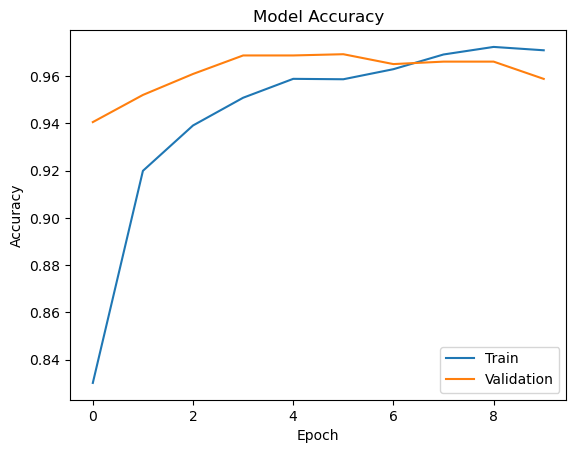

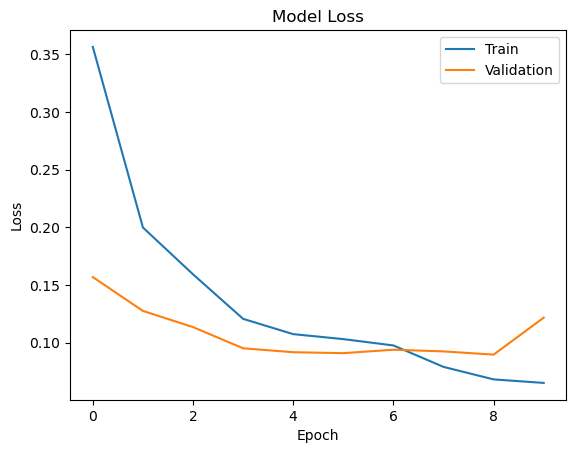

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_fine.history['accuracy'])
plt.plot(history_fine.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.savefig("accuracy_plot.png")
plt.show()

plt.figure()
plt.plot(history_fine.history['loss'])
plt.plot(history_fine.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.savefig("loss_plot.png")
plt.show()

In [23]:
import pickle

with open("training_history.pkl", "wb") as f:
    pickle.dump(history_fine.history, f)

In [24]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

29/29 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9512 - loss: 0.1567
Test Loss: 0.1567370742559433
Test Accuracy: 0.9512194991111755


In [25]:
import numpy as np

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

29/29 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step


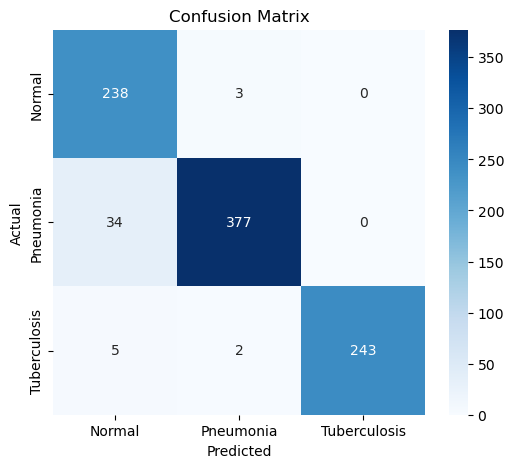

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys()
))

              precision    recall  f1-score   support

      Normal       0.86      0.99      0.92       241
   Pneumonia       0.99      0.92      0.95       411
Tuberculosis       1.00      0.97      0.99       250

    accuracy                           0.95       902
   macro avg       0.95      0.96      0.95       902
weighted avg       0.96      0.95      0.95       902



In [28]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

In [29]:
n_classes = 3

y_true_bin = label_binarize(y_true, classes=[0,1,2])

In [30]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

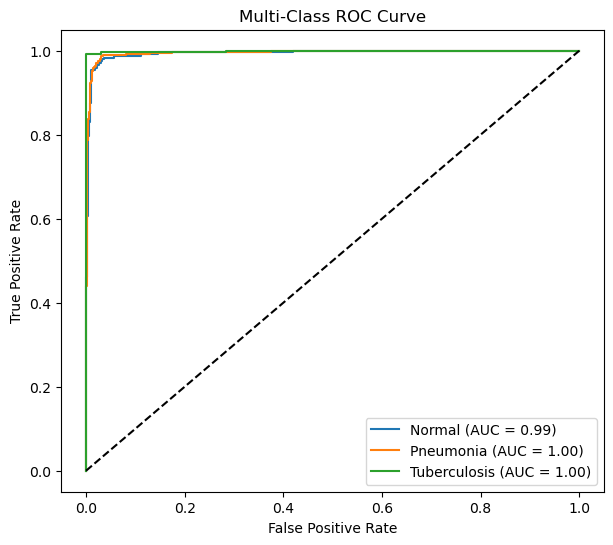

In [31]:
plt.figure(figsize=(7,6))

class_names = list(test_generator.class_indices.keys())

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1], [0,1], 'k--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

In [32]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [33]:
last_conv_layer_name = "conv5_block3_out"

In [34]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

In [35]:
img_path = test_generator.filepaths[0]  # pick first test image

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

In [36]:
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

C:\Users\User\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


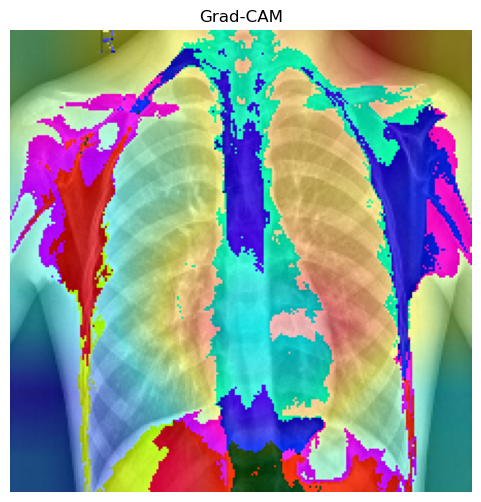

In [37]:
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(np.uint8(superimposed_img), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Grad-CAM")
plt.show()

In [38]:
model.save("Final_Pneumonia_TB_ResNet50.keras")

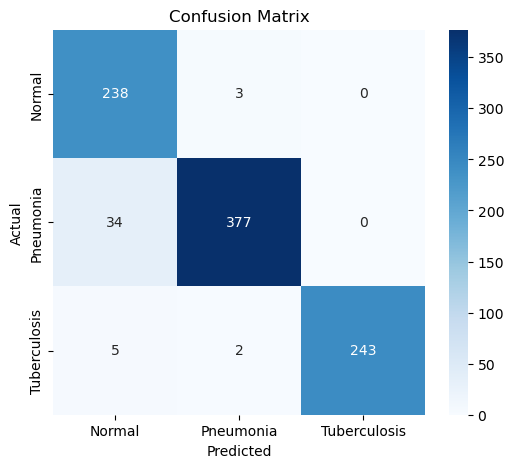

In [39]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

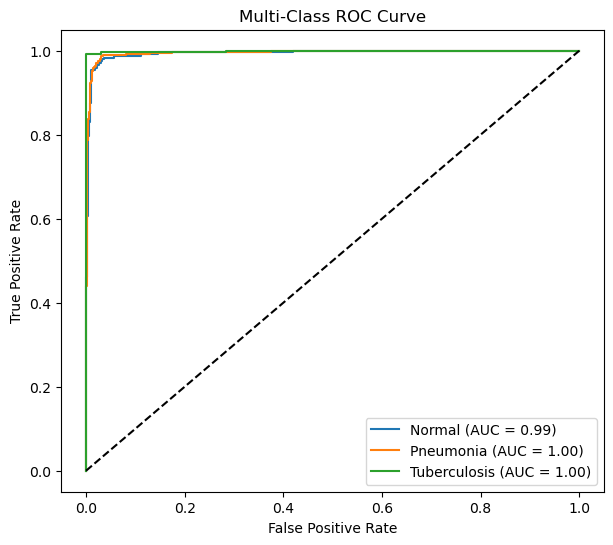

In [40]:
plt.figure(figsize=(7,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()

plt.savefig("roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

In [1]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image size and batch size again
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Create test datagen (same as validation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Recreate test generator
test_generator = val_test_datagen.flow_from_directory(
    "combined_dataset/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Print actual class order
print("Class indices mapping:")
print(test_generator.class_indices)

Found 902 images belonging to 3 classes.
Class indices mapping:
{'Normal': 0, 'Pneumonia': 1, 'Tuberculosis': 2}


In [5]:
from tensorflow.keras.models import load_model

model = load_model("Final_Pneumonia_TB_ResNet50.keras")

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 52,506,507 (200.30 MB)

 Trainable params: 14,456,323 (55.15 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

 Optimizer params: 28,912,648 (110.29 MB)

In [6]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer).__name__)

0 input_layer InputLayer
1 conv1_pad ZeroPadding2D
2 conv1_conv Conv2D
3 conv1_bn BatchNormalization
4 conv1_relu Activation
5 pool1_pad ZeroPadding2D
6 pool1_pool MaxPooling2D
7 conv2_block1_1_conv Conv2D
8 conv2_block1_1_bn BatchNormalization
9 conv2_block1_1_relu Activation
10 conv2_block1_2_conv Conv2D
11 conv2_block1_2_bn BatchNormalization
12 conv2_block1_2_relu Activation
13 conv2_block1_0_conv Conv2D
14 conv2_block1_3_conv Conv2D
15 conv2_block1_0_bn BatchNormalization
16 conv2_block1_3_bn BatchNormalization
17 conv2_block1_add Add
18 conv2_block1_out Activation
19 conv2_block2_1_conv Conv2D
20 conv2_block2_1_bn BatchNormalization
21 conv2_block2_1_relu Activation
22 conv2_block2_2_conv Conv2D
23 conv2_block2_2_bn BatchNormalization
24 conv2_block2_2_relu Activation
25 conv2_block2_3_conv Conv2D
26 conv2_block2_3_bn BatchNormalization
27 conv2_block2_add Add
28 conv2_block2_out Activation
29 conv2_block3_1_conv Conv2D
30 conv2_block3_1_bn BatchNormalization
31 conv2_block3_1_re

In [7]:
last_conv_layer = model.get_layer("conv5_block3_out")

print("Layer Name:", last_conv_layer.name)
print("Layer Type:", type(last_conv_layer).__name__)
print("Output Shape:", last_conv_layer.output.shape)

Layer Name: conv5_block3_out
Layer Type: Activation
Output Shape: (None, 7, 7, 2048)


In [8]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [9]:
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer("conv5_block3_out").output,
        model.output
    ]
)

print("Grad-CAM model created successfully!")

Grad-CAM model created successfully!


In [10]:
print("Model Input:", model.input_shape)
print("Model Output:", model.output_shape)
print("Grad-CAM Layer:", model.get_layer("conv5_block3_out").output.shape)

Model Input: (None, 224, 224, 3)
Model Output: (None, 3)
Grad-CAM Layer: (None, 7, 7, 2048)


In [11]:
import tensorflow as tf

# Select final ResNet50 feature-map layer
last_conv_layer = model.get_layer("conv5_block3_out")

# Create Grad-CAM model
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        last_conv_layer.output,
        model.output
    ]
)

print("Grad-CAM model created successfully!")
print("Model Input:", model.input_shape)
print("Model Output:", model.output_shape)
print("Grad-CAM Layer:", last_conv_layer.output.shape)

Grad-CAM model created successfully!
Model Input: (None, 224, 224, 3)
Model Output: (None, 3)
Grad-CAM Layer: (None, 7, 7, 2048)


In [12]:
!pip install opencv-python

  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.


In [13]:
import cv2

In [2]:
import sys
!{sys.executable} -m pip install --force-reinstall numpy==1.26.4

  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.


In [3]:
import numpy as np
import tensorflow as tf
import cv2

print(np.__version__)
print(tf.__version__)
print(cv2.__version__)

1.26.4
2.16.1
4.10.0


In [4]:
import sys
print(sys.executable)

import numpy as np
print(np.__version__)

C:\Users\User\anaconda3\envs\pneumonia_ai\python.exe
1.26.4


In [5]:
!pip install opencv-python

In [1]:
import sys
print(sys.executable)

C:\Users\User\anaconda3\envs\pneumonia_ai\python.exe


In [ ]:
!streamlit run streamlit_app.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://10.28.83.175:8501



2026-07-22 22:32:32.453 Uvicorn server started on :::8501


In [3]:
from tensorflow.keras.models import load_model

model = load_model("Final_Pneumonia_TB_ResNet50.keras")

print("Model Loaded Successfully")

Model Loaded Successfully


In [4]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    r"C:\Users\User\Desktop\Pneumonia & TB Detection\pneumonia_data\test\PNEUMONIA\person1_virus_7_jpeg.rf.f665f80c2ff0c3f841ca38ccf1bcc2ef.jpg",
    target_size=(224,224)
)
img = image.img_to_array(img)
img = img / 255.0
img = np.expand_dims(img, axis=0)
pred = model.predict(img)
from tensorflow.keras.applications.resnet50 import preprocess_input

img = image.img_to_array(img)
img = np.expand_dims(img, axis=0)
img = preprocess_input(img)
print("Prediction:", pred)
print("Predicted Class Index:", np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


ValueError: Unsupported image shape: (1, 224, 224, 3)